In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt

ROOT = Path(
    "/kaggle/input/competitions/rsna-knee-abnormality-detection"
)

train = pd.read_csv(ROOT / "train.csv")
series = pd.read_csv(ROOT / "train_series.csv")

study_id = train["StudyInstanceUID"].iloc[0]
study_series = series[
    series["StudyInstanceUID"] == study_id
].copy()

series_id = study_series["SeriesInstanceUID"].iloc[0]
series_folder = ROOT / "train_series" / study_id / series_id

dicom_files = sorted(series_folder.glob("*.dcm"))
assert dicom_files, "No DICOM files found. Check the dataset path."

# Ordering the files based on their geometry

In [2]:
headers = [
    pydicom.dcmread(path, stop_before_pixels=True)
    for path in dicom_files
]

orientations = np.array([
    ds.ImageOrientationPatient for ds in headers
], dtype=float)

assert np.allclose(
    orientations, orientations[0], atol=1e-4, rtol=0
), "Slice orientations differ; inspect before stacking."

normal = np.cross(orientations[0, :3], orientations[0, 3:])
normal = normal / np.linalg.norm(normal)

positions = np.array([
    ds.ImagePositionPatient for ds in headers
], dtype=float)

order = np.argsort(positions @ normal)
ordered_files = [dicom_files[i] for i in order]

# Visualizing the volume, grid-by-grid

Volume shape: (22, 512, 512)


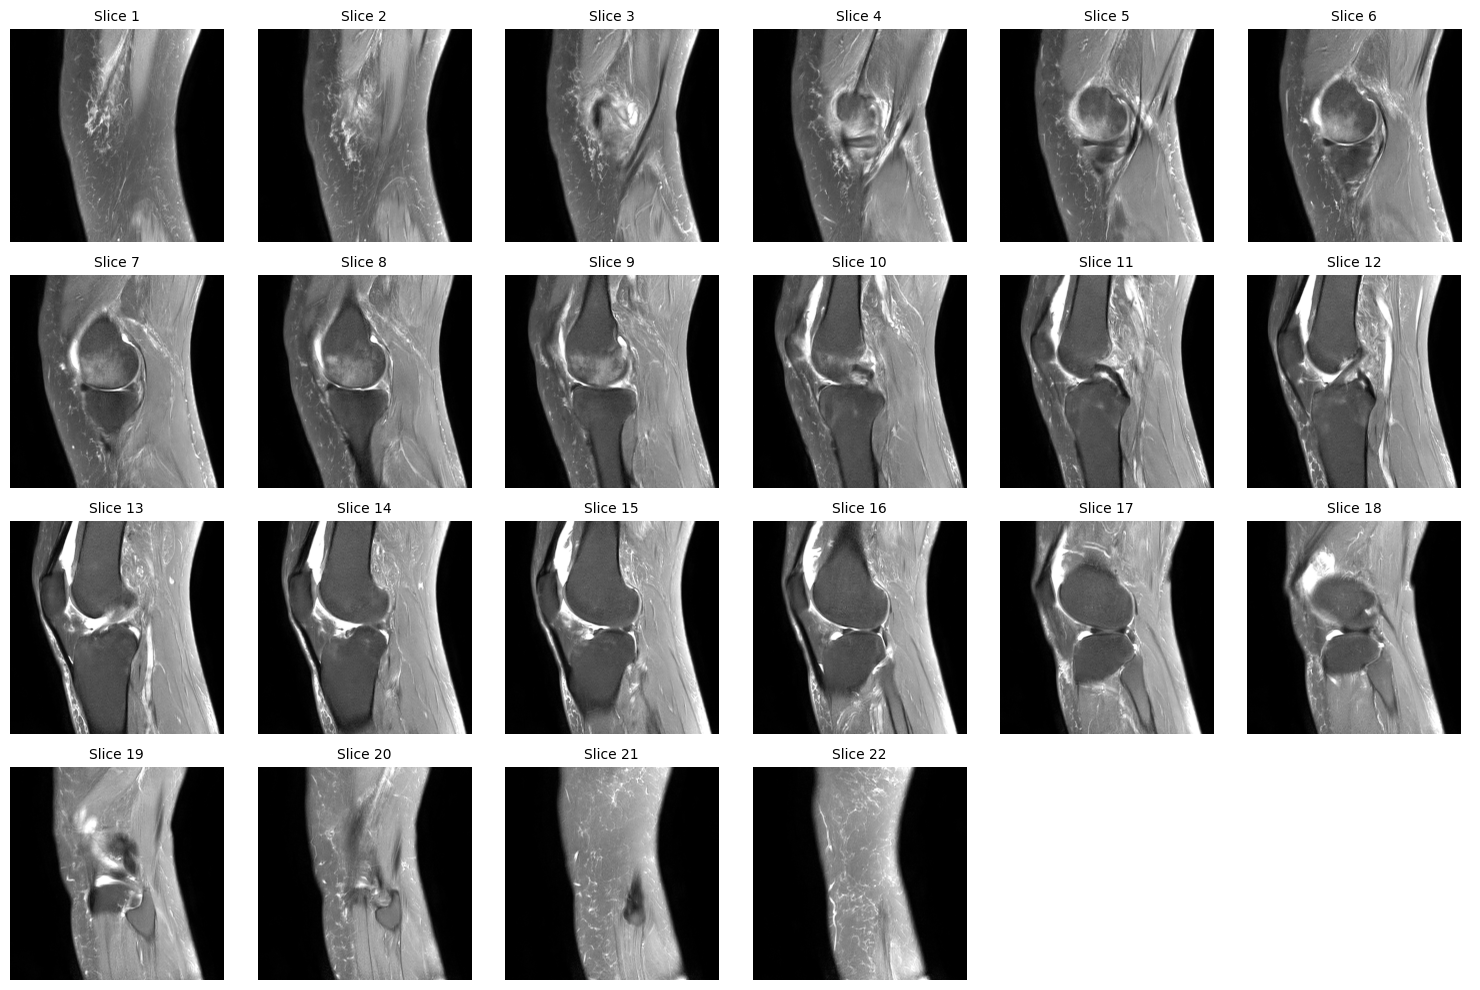

In [3]:
volume = np.stack([
    pydicom.dcmread(path).pixel_array
    for path in ordered_files
])

print("Volume shape:", volume.shape)

vmin, vmax = np.percentile(volume, [1, 99])

ncols = 6
nrows = int(np.ceil(len(volume) / ncols))

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(15, 2.5 * nrows),
    squeeze=False,
)

for i, ax in enumerate(axes.ravel()):
    if i < len(volume):
        ax.imshow(
            volume[i],
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f"Slice {i + 1}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

# A Closer Look

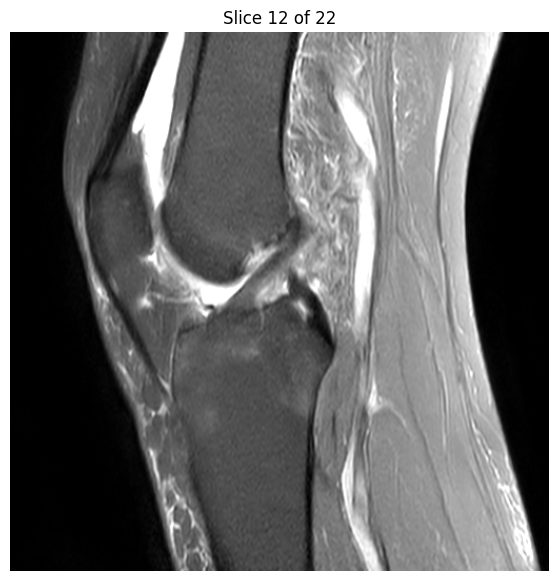

In [4]:
slice_index = len(volume) // 2 #Changing this to have a different view of each knee image  
# This outputs: 12 (the middle part of the knee), can change it directly into a number

plt.figure(figsize=(7, 7))
plt.imshow(
    volume[slice_index],
    cmap="gray",
    vmin=vmin,
    vmax=vmax,
)
plt.title(f"Slice {slice_index + 1} of {len(volume)}")
plt.axis("off")
plt.show()

# Comparing view orientation --> Sagittal, Coronal, and Axial View

In [5]:
def get_middle_slice(series_folder):
    files = sorted(series_folder.glob("*.dcm"))
    if not files:
        raise FileNotFoundError(f"No DICOM files in {series_folder}")

    headers = [
        pydicom.dcmread(path, stop_before_pixels=True)
        for path in files
    ]

    orientations = np.array([
        ds.ImageOrientationPatient for ds in headers
    ], dtype=float)

    if not np.allclose(
        orientations, orientations[0], atol=1e-4, rtol=0
    ):
        raise ValueError("Slice orientations differ; inspect this series.")

    normal = np.cross(orientations[0, :3], orientations[0, 3:])
    normal = normal / np.linalg.norm(normal)

    positions = np.array([
        ds.ImagePositionPatient for ds in headers
    ], dtype=float)

    order = np.argsort(positions @ normal)
    middle_index = order[len(order) // 2]

    ds = pydicom.dcmread(files[middle_index])

    return ds.pixel_array, ds, len(files)

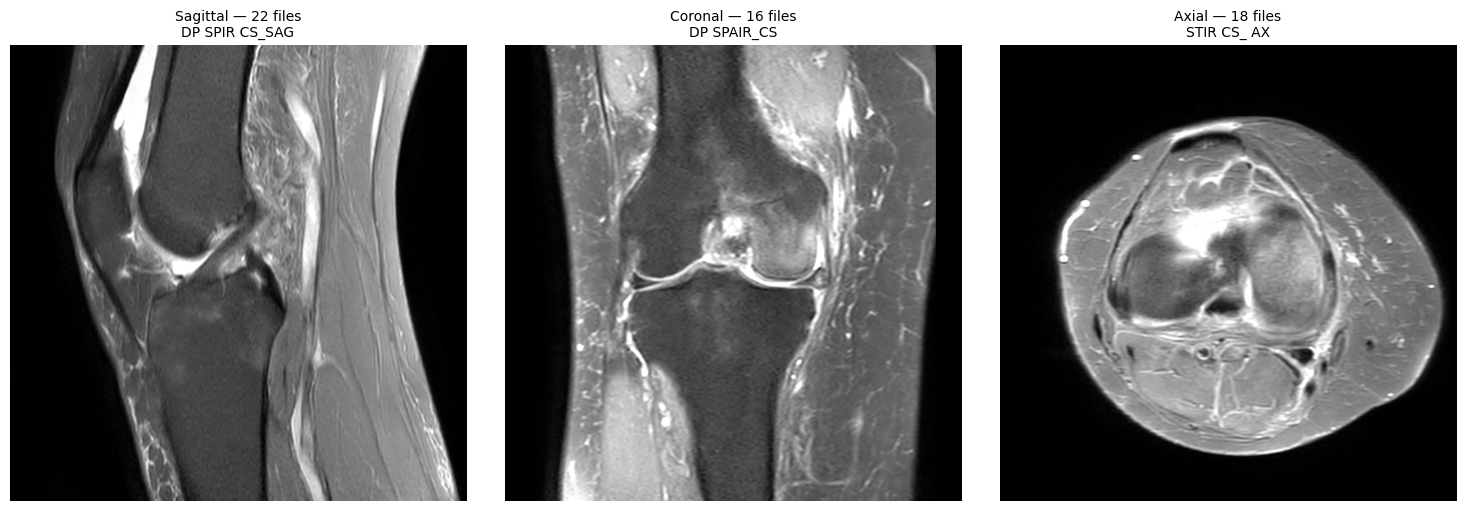

In [6]:
planes = ["Sagittal", "Coronal", "Axial"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, plane in zip(axes, planes):
    candidates = study_series[
        study_series["Anatomical_Plane"] == plane
    ]

    # For this comparison, select a series with both flags set to 1.
    candidates = candidates[
        candidates["Fluid_Sensitive"].eq(1)
        & candidates["Fat_Suppression"].eq(1)
    ]

    if candidates.empty:
        ax.set_title(f"{plane}: no matching series")
        ax.axis("off")
        continue

    chosen = candidates.iloc[0]
    folder = (
        ROOT / "train_series"
        / study_id / chosen["SeriesInstanceUID"]
    )

    image, ds, count = get_middle_slice(folder)

    low, high = np.percentile(image, [1, 99])
    row_spacing, col_spacing = map(float, ds.PixelSpacing)

    ax.imshow(
        image,
        cmap="gray",
        vmin=low,
        vmax=high,
        aspect=row_spacing / col_spacing,
    )

    ax.set_title(
        f"{plane} — {count} files\n"
        f"{getattr(ds, 'SeriesDescription', '')}",
        fontsize=10,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

# Image props digging to decide normalization

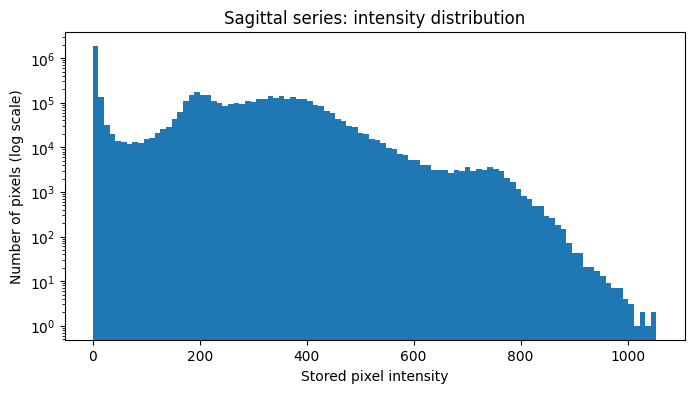

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(volume.ravel(), bins=100, log=True)

plt.xlabel("Stored pixel intensity")
plt.ylabel("Number of pixels (log scale)")
plt.title("Sagittal series: intensity distribution")
plt.show()

In [8]:
percentiles = [0, 1, 25, 50, 75, 99, 100]

display(pd.DataFrame({
    "Percentile": percentiles,
    "Stored intensity": np.percentile(volume, percentiles),
}))

print(f"Exactly-zero pixels: {(volume == 0).mean():.1%}")

,Percentile,Stored intensity
0,0,0.0
1,1,0.0
2,25,4.0
3,50,206.0
4,75,342.0
5,99,611.0
6,100,1054.0


Exactly-zero pixels: 6.1%
